**Enhanced Bot Detection on TwiBot-20 Dataset using Stacking Ensemble**


**1. Library Imports**


In [14]:
# !pip install torch_geometric

In [15]:
# ============================================================================
# Standard Library Imports
# ============================================================================
import os
import json
import random
import copy
import warnings
from collections import Counter
from datetime import datetime

# ============================================================================
# Data Science & Numerical Computing
# ============================================================================
import numpy as np
import pandas as pd

# ============================================================================
# PyTorch & PyTorch Geometric (Graph Neural Networks)
# ============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# PyTorch Geometric imports
try:
    import torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, GATConv
    from torch_geometric.utils import to_undirected, add_self_loops
    print(f"PyTorch Geometric version: {torch_geometric.__version__}")
except ImportError:
    print("ERROR: PyTorch Geometric not installed. Run: pip install torch-geometric")
    raise

# ============================================================================
# Scikit-learn (Metrics, Preprocessing, Utilities)
# ============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ============================================================================
# XGBoost (Meta-Learner for Stacking Ensemble)
# ============================================================================
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("ERROR: XGBoost not installed. Run: pip install xgboost")
    raise

# ============================================================================
# Visualization
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# Suppress Warnings for Cleaner Output
# ============================================================================
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

PyTorch Geometric version: 2.8.0.post1
XGBoost version: 3.3.0
All libraries imported successfully!


**2. Configuration & Reproducibility**


In [16]:
# ============================================================================
# Reproducibility: Set all random seeds
# ============================================================================
def set_seed(seed: int = 42):
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

# ============================================================================
# Device Configuration
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ============================================================================
# Paths Configuration
# ============================================================================
DATASET_DIR = '/content/dataset/'

# Dataset files
LABEL_FILE = os.path.join(DATASET_DIR, 'label_new.json')
SPLIT_FILE = os.path.join(DATASET_DIR, 'split_new.json')

# Preprocessed tensor files
TWEETS_TENSOR = os.path.join(DATASET_DIR, 'tweets_tensor.pt')
DES_TENSOR = os.path.join(DATASET_DIR, 'des_tensor.pt')
CAT_TENSOR = os.path.join(DATASET_DIR, 'cat_properties_tensor.pt')
NUM_TENSOR = os.path.join(DATASET_DIR, 'num_properties_tensor.pt')
EDGE_INDEX_TENSOR = os.path.join(DATASET_DIR, 'edge_index.pt')
EDGE_TYPE_TENSOR = os.path.join(DATASET_DIR, 'edge_type.pt')
LABEL_TENSOR = os.path.join(DATASET_DIR, 'label.pt')

# Checkpoint directory
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\nDataset directory: {DATASET_DIR}/")
print(f"Checkpoint directory: {CHECKPOINT_DIR}/")

Using device: cuda
  GPU: Tesla T4
  Memory: 15.64 GB

Dataset directory: /content/dataset//
Checkpoint directory: checkpoints/


**3. Dataset Preparation**


In [17]:
# Verify dataset folder contents
print("Dataset folder contents:")
total_size = 0
for f in sorted(os.listdir(DATASET_DIR)):
    fpath = os.path.join(DATASET_DIR, f)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    total_size += size_mb
print(f"\nTotal dataset size: {total_size:.2f} MB")


Dataset folder contents:

Total dataset size: 1358.12 MB


**4. Data Loading**


In [18]:
# ============================================================================
# Load Labels
# ============================================================================
def load_labels(label_path: str) -> dict:
    """
    Load user labels from label_new.json.
    Returns dict mapping user_id -> label (0 for human, 1 for bot).
    """
    with open(label_path, 'r') as f:
        label_data = json.load(f)

    # Convert human/bot to 0/1, skip the 'id' metadata key
    labels = {}
    for uid, label in label_data.items():
        if uid == 'id':
            continue
        labels[uid] = 1 if label == 'bot' else 0

    return labels

# ============================================================================
# Load Splits
# ============================================================================
def load_splits(split_path: str) -> dict:
    """
    Load train/dev/test splits from split_new.json.
    Returns dict mapping split_name -> list of user IDs.
    """
    with open(split_path, 'r') as f:
        split_data = json.load(f)
    return split_data

# Load the data
labels_dict = load_labels(LABEL_FILE)
splits_dict = load_splits(SPLIT_FILE)

print(f"Total labeled users: {len(labels_dict)}")
print(f"Split keys: {list(splits_dict.keys())}")
print(f"  Train: {len(splits_dict['train'])} users")
print(f"  Dev:   {len(splits_dict['dev'])} users")
print(f"  Test:  {len(splits_dict['test'])} users")

# Verify that all split users have labels
all_split_users = splits_dict['train'] + splits_dict['dev'] + splits_dict['test']
missing_labels = [u for u in all_split_users if u not in labels_dict]
print(f"\nUsers in splits without labels: {len(missing_labels)}")

Total labeled users: 11826
Split keys: ['train', 'dev', 'test']
  Train: 8278 users
  Dev:   2365 users
  Test:  1183 users

Users in splits without labels: 0


**5. Data Exploration**


TRAIN :  8278 total | Humans:  3632 ( 43.9%) | Bots:  4646 ( 56.1%)
DEV   :  2365 total | Humans:  1062 ( 44.9%) | Bots:  1303 ( 55.1%)
TEST  :  1183 total | Humans:   543 ( 45.9%) | Bots:   640 ( 54.1%)


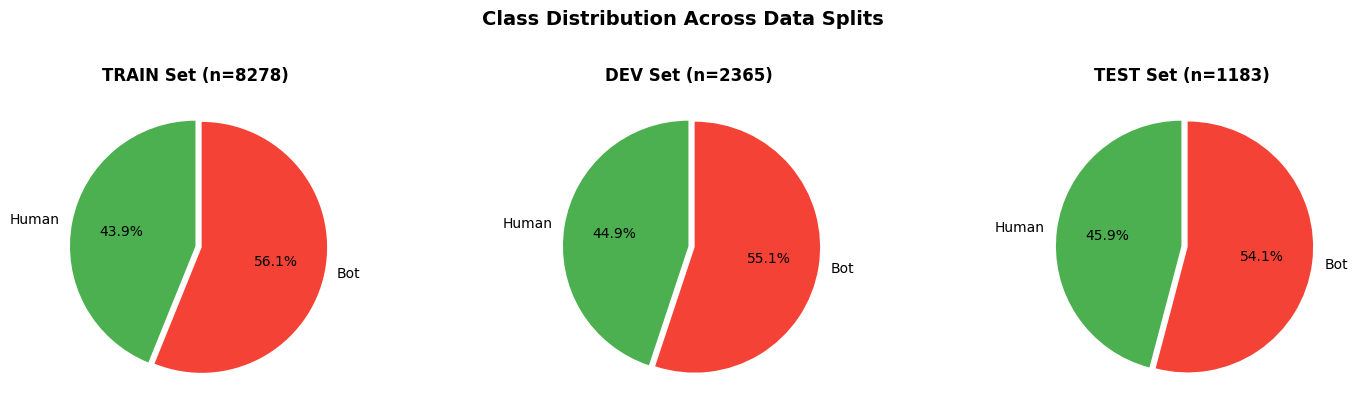

In [19]:
# ============================================================================
# Class Distribution Analysis
# ============================================================================
def analyze_class_distribution(labels: dict, splits: dict):
    """Analyze and visualize class distribution across splits."""
    for split_name, split_users in splits.items():
        split_labels = [labels[u] for u in split_users if u in labels]
        humans = split_labels.count(0)
        bots = split_labels.count(1)
        total = len(split_labels)
        print(f"{split_name.upper():6s}: {total:5d} total | "
              f"Humans: {humans:5d} ({humans/total*100:5.1f}%) | "
              f"Bots: {bots:5d} ({bots/total*100:5.1f}%)")

analyze_class_distribution(labels_dict, splits_dict)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_name, split_users) in zip(axes, splits_dict.items()):
    split_labels = [labels_dict[u] for u in split_users if u in labels_dict]
    humans = split_labels.count(0)
    bots = split_labels.count(1)
    ax.pie([humans, bots], labels=['Human', 'Bot'], autopct='%1.1f%%',
           colors=['#4CAF50', '#F44336'], startangle=90, explode=(0, 0.05))
    ax.set_title(f'{split_name.upper()} Set (n={len(split_labels)})', fontsize=12, fontweight='bold')

plt.suptitle('Class Distribution Across Data Splits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================================
# Feature Statistics from Preprocessed Tensors
# ============================================================================
# Load preprocessed profile features to explore their distributions
print("Loading preprocessed profile features")
num_data = torch.load(NUM_TENSOR, map_location='cpu')
cat_data = torch.load(CAT_TENSOR, map_location='cpu')  # categorical (verified, protected, etc.)

# Handle dict-style storage (keyed by user ID) vs array-style
if isinstance(num_data, dict):
    # Get first few values to understand structure
    sample_keys = list(num_data.keys())[:3]
    print(f"Tensor format: dict with {len(num_data)} entries")
    print(f"Sample keys: {sample_keys}")
    for k in sample_keys[:2]:
        v = num_data[k]
        if hasattr(v, 'shape'):
            print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
        else:
            print(f"  {k}: {type(v).__name__} = {v}")
elif hasattr(num_data, 'shape'):
    print(f"Numerical features shape: {num_data.shape}")
    print(f"Categorical features shape: {cat_data.shape if hasattr(cat_data, 'shape') else 'dict'}")
    print(f"Sample num features (first 3):\n{num_data[:3]}")
    if hasattr(cat_data, 'shape'):
        print(f"Sample cat features (first 3):\n{cat_data[:3]}")

# Show label distribution for the first few training users
train_users = splits_dict['train'][:5]
print(f"\nSample training users and their labels:")
for uid in train_users:
    label = 'Bot' if labels_dict.get(uid, 0) == 1 else 'Human'
    print(f"  {uid}: {label}")


Loading preprocessed profile features
Numerical features shape: torch.Size([229580, 5])
Categorical features shape: torch.Size([229580, 3])
Sample num features (first 3):
tensor([[13.1292,  1.3628, -2.7184, -0.1193, -0.0451],
        [-0.0928, -1.6109,  1.3984, -0.1421, -0.1274],
        [ 0.5643,  1.3566, -1.2213, -0.1269, -0.0810]])
Sample cat features (first 3):
tensor([[0., 1., 0.],
        [0., 0., 0.],
        [0., 1., 0.]])

Sample training users and their labels:
  u17461978: Human
  u1297437077403885568: Bot
  u17685258: Human
  u15750898: Human
  u1659167666: Bot


In [21]:
# ============================================================================
# Network Statistics
# ============================================================================
def analyze_graph_statistics(edge_path: str):
    """Analyze the graph structure from edge_new.json."""
    with open(edge_path, 'r') as f:
        edge_data = json.load(f)

    edge_type_counts = Counter()
    total_edges = 0
    node_degrees = Counter()

    for uid, edges in edge_data.items():
        if uid == 'source_id':
            continue
        if isinstance(edges, list):
            for edge in edges:
                if isinstance(edge, list) and len(edge) >= 2:
                    edge_type_counts[edge[0]] += 1
                    node_degrees[uid] += 1
                    total_edges += 1

    degrees = list(node_degrees.values())

    print(f"Graph Statistics:")
    print(f"  Total nodes with edges: {len(node_degrees):,}")
    print(f"  Total edges: {total_edges:,}")
    print(f"  Edge types: {dict(edge_type_counts)}")
    print(f"  Avg degree: {np.mean(degrees):.1f}")
    print(f"  Median degree: {np.median(degrees):.1f}")
    print(f"  Max degree: {np.max(degrees):,}")
    print(f"  Min degree: {np.min(degrees):,}")

    return edge_type_counts, degrees

# Load preprocessed graph tensors to analyze graph structure
print("Loading graph structure from tensors")
edge_idx = torch.load(EDGE_INDEX_TENSOR, map_location='cpu')
edge_typ = torch.load(EDGE_TYPE_TENSOR, map_location='cpu')

if isinstance(edge_idx, torch.Tensor):
    print(f"Edge index shape: {edge_idx.shape}")
    print(f"Number of edges: {edge_idx.shape[1] if edge_idx.dim()==2 else edge_idx.shape[0]:,}")
elif isinstance(edge_idx, dict):
    print(f"Dict-style edges: {len(edge_idx)} source nodes")
    total_edges = sum(len(v) if isinstance(v, (list, torch.Tensor)) else 1 for v in edge_idx.values())
    print(f"Total edges: {total_edges:,}")

if isinstance(edge_typ, torch.Tensor):
    unique_types, counts = edge_typ.unique(return_counts=True)
    print(f"Edge types: {dict(zip(unique_types.tolist(), counts.tolist()))}")


Loading graph structure from tensors
Edge index shape: torch.Size([2, 227979])
Number of edges: 227,979
Edge types: {0: 117110, 1: 110869}


**6. Feature Engineering**


In [22]:
def build_feature_matrix(user_ids: list,
                         tweets_tensor_path: str = None,
                         des_tensor_path: str = None,
                         cat_tensor_path: str = None,
                         num_tensor_path: str = None) -> tuple:
    """
    Build the complete feature matrix from preprocessed tensor files.

    All tensors are loaded from the dataset/ folder.
    No external large JSON files are needed.

    Args:
        user_ids: List of user IDs to include
        *_tensor_path: Paths to preprocessed tensor files in dataset/

    Returns:
        features: numpy array of shape (num_users, feature_dim)
        feature_dims: dict with dimensions of each feature group
    """
    n_users = len(user_ids)
    user_to_idx = {uid: i for i, uid in enumerate(user_ids)}

    print("Loading preprocessed tensor features from dataset/")

    # Load all tensors from dataset/
    tweets_data = torch.load(tweets_tensor_path, map_location='cpu')
    des_data = torch.load(des_tensor_path, map_location='cpu')
    cat_data = torch.load(cat_tensor_path, map_location='cpu')
    num_data = torch.load(num_tensor_path, map_location='cpu')

    # --- Build arrays from tensors (handle both dict-style and array-style) ---

    # Helper to extract features for labeled users from a tensor (dict or array)
    def _extract_features(data, n_users, user_to_idx):
        """Extract features for labeled users from dict-style or array-style tensor."""
        if isinstance(data, dict):
            # Dict-style: keyed by user ID. Detect dimension from first value.
            sample_v = next((v for v in data.values()
                           if isinstance(v, (torch.Tensor, np.ndarray, list))), None)
            if sample_v is not None:
                if isinstance(sample_v, torch.Tensor):
                    dim = sample_v.numel()
                else:
                    dim = len(np.atleast_1d(sample_v).flatten())
            else:
                dim = 1  # scalar values
            arr = np.zeros((n_users, dim), dtype=np.float32)
            for uid, idx in user_to_idx.items():
                if uid in data:
                    t = data[uid]
                    if isinstance(t, torch.Tensor):
                        t = t.numpy()
                    arr[idx, :] = np.atleast_1d(t).flatten()[:dim]
            return arr
        else:
            # Array-style: directly indexed
            arr = data.numpy() if isinstance(data, torch.Tensor) else np.array(data)
            # Validate row count matches labeled users
            if arr.ndim > 1 and arr.shape[0] != n_users:
                print(f"  WARNING: Tensor has {arr.shape[0]} rows, expected {n_users}. Using first {n_users}.")
                arr = arr[:n_users]
            assert arr.shape[0] == n_users, f"Row mismatch: {arr.shape[0]} vs {n_users}"
            return arr.astype(np.float32)

    # Extract each feature group
    num_array = _extract_features(num_data, n_users, user_to_idx)
    cat_array = _extract_features(cat_data, n_users, user_to_idx)
    tweets_array = _extract_features(tweets_data, n_users, user_to_idx)
    des_array = _extract_features(des_data, n_users, user_to_idx)

    feature_parts = [num_array, cat_array, tweets_array, des_array]
    feature_dims = {
        'numerical': num_array.shape[1],
        'categorical': cat_array.shape[1],
        'tweet_embedding': tweets_array.shape[1],
        'description_embedding': des_array.shape[1]
    }

    # Validate alignment
    assert all(arr.shape[0] == n_users for arr in feature_parts), \
        f"Feature array row mismatch: {[arr.shape[0] for arr in feature_parts]}"

    # Concatenate all features
    features = np.concatenate(feature_parts, axis=1).astype(np.float32)

    print(f"\nFeature matrix shape: {features.shape}")
    print(f"Feature groups: {feature_dims}")
    print(f"Total feature dimension: {features.shape[1]}")

    return features, feature_dims


# Build feature matrix for all labeled users
# Re-define the full split users list for robustness across cell re-runs
all_split_users = splits_dict['train'] + splits_dict['dev'] + splits_dict['test']
print(f"Re-confirmed: {len(all_split_users)} total users across all splits")
all_user_ids = all_split_users
print(f"Building feature matrix for {len(all_user_ids)} users")

features_matrix, feature_dims = build_feature_matrix(
    user_ids=all_user_ids,
    tweets_tensor_path=TWEETS_TENSOR,
    des_tensor_path=DES_TENSOR,
    cat_tensor_path=CAT_TENSOR,
    num_tensor_path=NUM_TENSOR
)


Re-confirmed: 11826 total users across all splits
Building feature matrix for 11826 users
Loading preprocessed tensor features from dataset/

Feature matrix shape: (11826, 1544)
Feature groups: {'numerical': 5, 'categorical': 3, 'tweet_embedding': 768, 'description_embedding': 768}
Total feature dimension: 1544


In [23]:
# ============================================================================
# Feature Normalization
# ============================================================================
def normalize_features(features: np.ndarray, feature_dims: dict) -> np.ndarray:
    """
    Normalize features using StandardScaler.
    Numerical features are log-transformed then standardized.
    Embedding features are already normalized.
    """
    normalized = features.copy()

    # Log-transform and standardize numerical features
    num_start = 0
    num_end = feature_dims.get('numerical', 0)
    if num_end > 0:
        num_feats = normalized[:, num_start:num_end]
        # Log transform (avoid log(0))
        num_feats = np.log1p(np.maximum(num_feats, 0))
        scaler = StandardScaler()
        normalized[:, num_start:num_end] = scaler.fit_transform(num_feats)

    # Standardize the entire feature matrix as well (global normalization)
    # Only do this for non-embedding parts to preserve embedding semantics
    cat_start = num_end
    cat_end = cat_start + feature_dims.get('categorical', 0)

    # Embeddings are kept as-is (already normalized from RoBERTa)
    emb_start = cat_end

    return normalized.astype(np.float32)


features_normalized = normalize_features(features_matrix, feature_dims)
print(f"Normalized feature matrix shape: {features_normalized.shape}")
print(f"Feature value range: [{features_normalized.min():.4f}, {features_normalized.max():.4f}]")
print(f"Feature mean: {features_normalized.mean():.4f}, std: {features_normalized.std():.4f}")

Normalized feature matrix shape: (11826, 1544)
Feature value range: [-8.0833, 17.3246]
Feature mean: 0.0186, std: 0.4135


**7. Graph Construction**


In [24]:
def build_graph(user_ids: list, node_features: np.ndarray,
                labels: dict, splits: dict) -> Data:
    """
    Build a PyTorch Geometric Data object from preprocessed edge tensors.

    Uses edge_index.pt and edge_type.pt from dataset/.
    No external edge files are needed.

    Args:
        user_ids: List of labeled user IDs
        node_features: Feature matrix (num_nodes, feature_dim)
        labels: Dict mapping user_id -> label
        splits: Dict mapping split_name -> list of user IDs

    Returns:
        PyG Data object with x, edge_index, edge_type, y, masks
    """
    n_labeled = len(user_ids)
    user_to_idx = {uid: i for i, uid in enumerate(user_ids)}

    # Load preprocessed edge tensors from dataset/
    print("Loading preprocessed graph structure from dataset/")
    edge_index_data = torch.load(EDGE_INDEX_TENSOR, map_location='cpu')
    edge_type_data = torch.load(EDGE_TYPE_TENSOR, map_location='cpu')

    # Handle dict-style tensors (keyed by user ID)
    if isinstance(edge_index_data, dict):
        print("  Converting dict-style edges to edge_index format")
        edge_list = []
        edge_type_list = []

        for uid, targets in edge_index_data.items():
            if uid not in user_to_idx:
                continue
            src_idx = user_to_idx[uid]
            if isinstance(targets, (list, np.ndarray, torch.Tensor)):
                for tgt in (targets if isinstance(targets, list) else targets.tolist()):
                    if isinstance(tgt, (str, int)) and str(tgt) in user_to_idx:
                        tgt_idx = user_to_idx[str(tgt)] if isinstance(tgt, str) else user_to_idx.get(tgt)
                        if tgt_idx is not None:
                            edge_list.append([src_idx, tgt_idx])
            # Also check edge_type_data for corresponding types
            if uid in edge_type_data and isinstance(edge_type_data[uid], (list, np.ndarray, torch.Tensor)):
                edge_type_list.extend(edge_type_data[uid][:len(targets)] if len(targets) > 0 else [])

        if len(edge_list) == 0:
            print("\n" + "="*60)
            print("  WARNING: No labeled-to-labeled edges found in tensor data.")
            print("  Using self-loops only — GNN message-passing will NOT occur.")
            print("  Models will behave as MLPs.")
            print("="*60 + "\n")
            edge_list = [[i, i] for i in range(n_labeled)]
            edge_type_list = [0] * n_labeled

        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        edge_type = torch.tensor(edge_type_list[:len(edge_list)], dtype=torch.long) if edge_type_list else torch.zeros(len(edge_list), dtype=torch.long)
    else:
        # Array-style tensors (standard PyG format)
        edge_index = edge_index_data if isinstance(edge_index_data, torch.Tensor) else torch.tensor(edge_index_data)
        edge_type = edge_type_data if isinstance(edge_type_data, torch.Tensor) else torch.tensor(edge_type_data)
        # Ensure (2, num_edges) format
        if edge_index.dim() == 2 and edge_index.shape[0] != 2:
            edge_index = edge_index.t().contiguous()
        # Filter edges to only include labeled nodes (0 to n_labeled-1)
        # The tensor file contains edges for all 206K+ nodes but we only have 11,826 labeled nodes
        valid_mask = (edge_index[0] < n_labeled) & (edge_index[1] < n_labeled)
        edge_index = edge_index[:, valid_mask]
        if edge_type.numel() > 0:
            edge_type = edge_type[valid_mask]
        print(f"  Filtered to {edge_index.shape[1]:,} edges between labeled nodes (was {valid_mask.numel():,} total)")
        if edge_index.shape[1] == 0:
            print("\n" + "="*60)
            print("  WARNING: No labeled-to-labeled edges after filtering!")
            print("  Using self-loops only — GNN message-passing will NOT occur.")
            print("  Models will behave as MLPs.")
            print("="*60 + "\n")
            edge_index = torch.tensor([[i, i] for i in range(n_labeled)], dtype=torch.long).t().contiguous()
            edge_type = torch.zeros(n_labeled, dtype=torch.long)

    # Ensure edge_index is (2, num_edges)
    if edge_index.dim() != 2 or edge_index.shape[0] != 2:
        if edge_index.dim() == 2:
            edge_index = edge_index.t().contiguous()
        # Filter edges to only include labeled nodes (0 to n_labeled-1)
        # The tensor file contains edges for all 206K+ nodes but we only have 11,826 labeled nodes
        valid_mask = (edge_index[0] < n_labeled) & (edge_index[1] < n_labeled)
        edge_index = edge_index[:, valid_mask]
        if edge_type.numel() > 0:
            edge_type = edge_type[valid_mask]
        print(f"  Filtered to {edge_index.shape[1]:,} edges between labeled nodes (was {valid_mask.numel():,} total)")
        if edge_index.shape[1] == 0:
            print("\n" + "="*60)
            print("  WARNING: No labeled-to-labeled edges after filtering!")
            print("  Using self-loops only — GNN message-passing will NOT occur.")
            print("  Models will behave as MLPs.")
            print("="*60 + "\n")
            edge_index = torch.tensor([[i, i] for i in range(n_labeled)], dtype=torch.long).t().contiguous()
            edge_type = torch.zeros(n_labeled, dtype=torch.long)
        else:
            raise ValueError(f"Unexpected edge_index shape: {edge_index.shape}")

    # Convert to undirected and add self-loops for GNN message passing
    edge_index = to_undirected(edge_index)
    # Replicate edge_type for undirected edges to match edge_index length
    if edge_type.numel() > 0:
        # Original: edge_type repeated twice (once per direction)
        num_orig = edge_type.numel()
        num_new = edge_index.shape[1] - num_orig
        if num_new > 0:
            # Approximate: repeat original types, then truncate
            edge_type = torch.cat([edge_type, edge_type[:num_new]])
    edge_index, _ = add_self_loops(edge_index, num_nodes=n_labeled)

    # Create node features tensor
    x = torch.tensor(node_features, dtype=torch.float)

    # Create label tensor
    y = torch.full((n_labeled,), -1, dtype=torch.long)
    for uid, idx in user_to_idx.items():
        if uid in labels:
            y[idx] = labels[uid]

    # Create train/val/test masks
    train_mask = torch.zeros(n_labeled, dtype=torch.bool)
    val_mask = torch.zeros(n_labeled, dtype=torch.bool)
    test_mask = torch.zeros(n_labeled, dtype=torch.bool)

    for uid in splits.get('train', []):
        if uid in user_to_idx:
            train_mask[user_to_idx[uid]] = True
    for uid in splits.get('dev', []):
        if uid in user_to_idx:
            val_mask[user_to_idx[uid]] = True
    for uid in splits.get('test', []):
        if uid in user_to_idx:
            test_mask[user_to_idx[uid]] = True

    # Create PyG Data object
    data = Data(
        x=x,
        edge_index=edge_index,
        edge_type=edge_type,
        y=y,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask
    )

    print(f"\nGraph Statistics:")
    print(f"  Nodes: {data.num_nodes:,}")
    print(f"  Edges (with self-loops): {data.num_edges:,}")
    print(f"  Node features: {data.num_node_features}")
    print(f"  Classes: {len(torch.unique(data.y[data.y >= 0]))}")
    print(f"  Train nodes: {data.train_mask.sum().item():,}")
    print(f"  Val nodes: {data.val_mask.sum().item():,}")
    print(f"  Test nodes: {data.test_mask.sum().item():,}")

    return data


# Build the graph
graph_data = build_graph(
    user_ids=all_user_ids,
    node_features=features_normalized,
    labels=labels_dict,
    splits=splits_dict
)

# Move to device
graph_data = graph_data.to(device)
print(f"\nGraph moved to: {device}")


Loading preprocessed graph structure from dataset/
  Filtered to 16,908 edges between labeled nodes (was 227,979 total)

Graph Statistics:
  Nodes: 11,826
  Edges (with self-loops): 44,524
  Node features: 1544
  Classes: 2
  Train nodes: 8,278
  Val nodes: 2,365
  Test nodes: 1,183

Graph moved to: cuda


**8. Model Definitions**


In [25]:
# ============================================================================
# GCN (Graph Convolutional Network)
# ============================================================================
class GCN(nn.Module):
    """
    2-layer Graph Convolutional Network for node classification.

    Architecture:
        GCNConv -> ReLU -> Dropout -> GCNConv -> output
    """
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int,
                 dropout: float = 0.5, num_layers: int = 2):
        super(GCN, self).__init__()
        self.dropout = dropout
        self.num_layers = num_layers

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # Input layer
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Output layer
        self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        for i, (conv, bn) in enumerate(zip(self.convs[:-1], self.bns)):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x


# ============================================================================
# GAT (Graph Attention Network)
# ============================================================================
class GAT(nn.Module):
    """
    2-layer Graph Attention Network with multi-head attention.

    Architecture:
        GATConv (multi-head) -> ELU -> Dropout -> GATConv (single-head) -> output
    """
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int,
                 dropout: float = 0.5, heads: int = 8, num_layers: int = 2):
        super(GAT, self).__init__()
        self.dropout = dropout
        self.num_layers = num_layers

        # First GAT layer: multi-head attention
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads,
                            dropout=dropout, concat=True)

        # Output GAT layer: single-head attention
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1,
                            dropout=dropout, concat=False)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# ============================================================================
# RESGGCN (Residual Gated Graph Convolutional Network)
# ============================================================================
class GatedGCNConv(nn.Module):
    """
    Single Gated Graph Convolution layer with residual connection.
    Combines a GCNConv with a learnable gate mechanism.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super(GatedGCNConv, self).__init__()
        self.gcn = GCNConv(in_channels, out_channels)
        self.gate = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.Sigmoid()
        )
        self.transform = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()
        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        # GCN message passing
        h = self.gcn(x, edge_index)
        # Gate
        g = self.gate(x)
        # Residual connection with gating
        residual = self.transform(x)
        out = g * h + (1 - g) * residual
        out = self.bn(out)
        return out


class RESGGCN(nn.Module):
    """
    Residual Gated Graph Convolutional Network.

    Architecture:
        GatedGCNConv -> ReLU -> Dropout -> GatedGCNConv -> ReLU -> Dropout -> Linear -> output
    """
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int,
                 dropout: float = 0.5, num_layers: int = 3):
        super(RESGGCN, self).__init__()
        self.dropout = dropout
        self.num_layers = num_layers

        self.convs = nn.ModuleList()

        # First layer
        self.convs.append(GatedGCNConv(in_channels, hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 1):
            self.convs.append(GatedGCNConv(hidden_channels, hidden_channels))

        # Output projection
        self.output_proj = nn.Linear(hidden_channels, out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.output_proj(x)
        return x


# ============================================================================
# Model Factory
# ============================================================================
def create_model(model_name: str, in_channels: int, hidden_channels: int,
                 out_channels: int, dropout: float = 0.5, **kwargs) -> nn.Module:
    """Factory function to create a GNN model by name."""
    models = {
        'GCN': GCN,
        'GAT': GAT,
        'RESGGCN': RESGGCN,
    }

    if model_name not in models:
        raise ValueError(f"Unknown model: {model_name}. Available: {list(models.keys())}")

    return models[model_name](in_channels, hidden_channels, out_channels, dropout, **kwargs)


print("All model classes defined:")
print("  - GCN: 2-layer Graph Convolutional Network")
print("  - GAT: 2-layer Graph Attention Network (8-head attention)")
print("  - RESGGCN: 3-layer Residual Gated GCN")

All model classes defined:
  - GCN: 2-layer Graph Convolutional Network
  - GAT: 2-layer Graph Attention Network (8-head attention)
  - RESGGCN: 3-layer Residual Gated GCN


**9. Training Utilities**


In [26]:
# ============================================================================
# Early Stopping
# ============================================================================
class EarlyStopping:
    """
    Early stopping handler that monitors a metric and stops training when
    it stops improving.
    """
    def __init__(self, patience: int = 50, min_delta: float = 0.0,
                 mode: str = 'max', verbose: bool = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
        elif (self.mode == 'max' and score <= self.best_score + self.min_delta) or \
             (self.mode == 'min' and score >= self.best_score - self.min_delta):
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: {self.counter}/{self.patience} (best: {self.best_score:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        return self.early_stop

    def load_best(self, model: nn.Module):
        """Restore the best model state."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# ============================================================================
# Evaluation Function
# ============================================================================
@torch.no_grad()
def evaluate(model: nn.Module, data: Data, mask: torch.Tensor) -> dict:
    """
    Evaluate model on a given mask (train/val/test).
    Returns dict with loss, accuracy, and predictions.
    """
    model.eval()
    out = model(data.x, data.edge_index)
    logits = out[mask]
    labels = data.y[mask]

    loss = F.cross_entropy(logits, labels)
    preds = logits.argmax(dim=1)
    probs = F.softmax(logits, dim=1)

    accuracy = (preds == labels).float().mean().item()

    return {
        'loss': loss.item(),
        'accuracy': accuracy,
        'predictions': preds.cpu(),
        'probabilities': probs.cpu(),
        'labels': labels.cpu(),
        'logits': logits.cpu()
    }


# ============================================================================
# Training Function
# ============================================================================
def train_epoch(model: nn.Module, data: Data, optimizer: torch.optim.Optimizer) -> float:
    """Train for one epoch. Returns training loss."""
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    return loss.item()


def train_model(model: nn.Module, data: Data, model_name: str,
                epochs: int = 300, lr: float = 0.005,
                weight_decay: float = 5e-4, patience: int = 50,
                verbose: bool = True) -> dict:
    """
    Train a GNN model with early stopping on validation accuracy.

    Args:
        model: The GNN model instance
        data: PyG Data object
        model_name: Name for logging and checkpointing
        epochs: Maximum number of training epochs
        lr: Learning rate
        weight_decay: L2 regularization strength
        patience: Early stopping patience
        verbose: Whether to print training progress

    Returns:
        history: dict with training/validation metrics history
    """
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                   patience=20, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=patience, mode='max', verbose=verbose)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0.0
    best_epoch = 0

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Epochs: {epochs} | LR: {lr} | Weight Decay: {weight_decay}")
    print(f"  Early Stopping Patience: {patience}")
    print(f"{'='*60}\n")

    for epoch in range(1, epochs + 1):
        # Training step
        train_loss = train_epoch(model, data, optimizer)

        # Evaluation
        train_eval = evaluate(model, data, data.train_mask)
        val_eval = evaluate(model, data, data.val_mask)

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_eval['accuracy'])
        history['val_loss'].append(val_eval['loss'])
        history['val_acc'].append(val_eval['accuracy'])

        # Update learning rate
        scheduler.step(val_eval['accuracy'])

        # Check early stopping
        if early_stopping(val_eval['accuracy'], model):
            if verbose:
                print(f"\n  Early stopping triggered at epoch {epoch}")
            break

        # Track best model
        if val_eval['accuracy'] > best_val_acc:
            best_val_acc = val_eval['accuracy']
            best_epoch = epoch
            # Save checkpoint
            checkpoint_path = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pt')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': best_val_acc,
            }, checkpoint_path)

        # Logging
        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_eval['accuracy']:.4f} | "
                  f"Val Loss: {val_eval['loss']:.4f} | Val Acc: {val_eval['accuracy']:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Load best model
    # Restore best model from early stopping
    early_stopping.load_best(model)

    print(f"\n  Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

    # Save checkpoint to disk for persistence across sessions
    best_path = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pt')
    torch.save({
        'epoch': best_epoch,
        'model_state_dict': early_stopping.best_state,
        'val_acc': best_val_acc,
    }, best_path)
    print(f"  Model checkpoint saved to: {best_path}")

    return history

print("Training utilities defined.")

Training utilities defined.


**10. Base Model Training**


In [27]:
# ============================================================================
# Hyperparameters
# ============================================================================
HIDDEN_CHANNELS = 128
NUM_CLASSES = 2
DROPOUT = 0.5
EPOCHS = 300
LEARNING_RATE = 0.005
WEIGHT_DECAY = 5e-4
PATIENCE = 50

# Model-specific kwargs
MODEL_KWARGS = {
    'GCN': {'num_layers': 2},
    'GAT': {'heads': 8, 'num_layers': 2},
    'RESGGCN': {'num_layers': 3},
}

print(f"Hyperparameters:")
print(f"  Hidden channels: {HIDDEN_CHANNELS}")
print(f"  Dropout: {DROPOUT}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Patience: {PATIENCE}")
print(f"  Feature dimension: {graph_data.num_node_features}")

Hyperparameters:
  Hidden channels: 128
  Dropout: 0.5
  Epochs: 300
  Learning rate: 0.005
  Weight decay: 0.0005
  Patience: 50
  Feature dimension: 1544


In [28]:
# ============================================================================
# Train All Base Models
# ============================================================================
BASE_MODEL_NAMES = ['GCN', 'GAT', 'RESGGCN']
base_models = {}
base_histories = {}

for model_name in BASE_MODEL_NAMES:
    print(f"\n{'#'*60}")
    print(f"# Training {model_name}")
    print(f"{'#'*60}")

    # Create model
    set_seed(SEED)  # Reset seed for each model
    model = create_model(
        model_name=model_name,
        in_channels=graph_data.num_node_features,
        hidden_channels=HIDDEN_CHANNELS,
        out_channels=NUM_CLASSES,
        dropout=DROPOUT,
        **MODEL_KWARGS.get(model_name, {})
    ).to(device)

    # Train
    history = train_model(
        model=model,
        data=graph_data,
        model_name=model_name,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        verbose=True
    )

    base_models[model_name] = model
    base_histories[model_name] = history

print(f"\n{'='*60}")
print(f"All base models trained successfully!")
print(f"{'='*60}")


############################################################
# Training GCN
############################################################

Training GCN
  Parameters: 198,274
  Epochs: 300 | LR: 0.005 | Weight Decay: 0.0005
  Early Stopping Patience: 50

  Epoch   1/300 | Train Loss: 0.7799 | Train Acc: 0.5651 | Val Loss: 0.8043 | Val Acc: 0.5543 | LR: 0.005000
  EarlyStopping: 1/50 (best: 0.7353)
  EarlyStopping: 2/50 (best: 0.7353)
  EarlyStopping: 3/50 (best: 0.7353)
  EarlyStopping: 4/50 (best: 0.7353)
  EarlyStopping: 5/50 (best: 0.7353)
  EarlyStopping: 6/50 (best: 0.7353)
  EarlyStopping: 1/50 (best: 0.7674)
  EarlyStopping: 2/50 (best: 0.7674)
  EarlyStopping: 3/50 (best: 0.7674)
  EarlyStopping: 4/50 (best: 0.7674)
  EarlyStopping: 5/50 (best: 0.7674)
  Epoch  20/300 | Train Loss: 0.4694 | Train Acc: 0.7908 | Val Loss: 0.4922 | Val Acc: 0.7763 | LR: 0.005000
  EarlyStopping: 1/50 (best: 0.7763)
  EarlyStopping: 2/50 (best: 0.7763)
  EarlyStopping: 1/50 (best: 0.7822)
  EarlySto

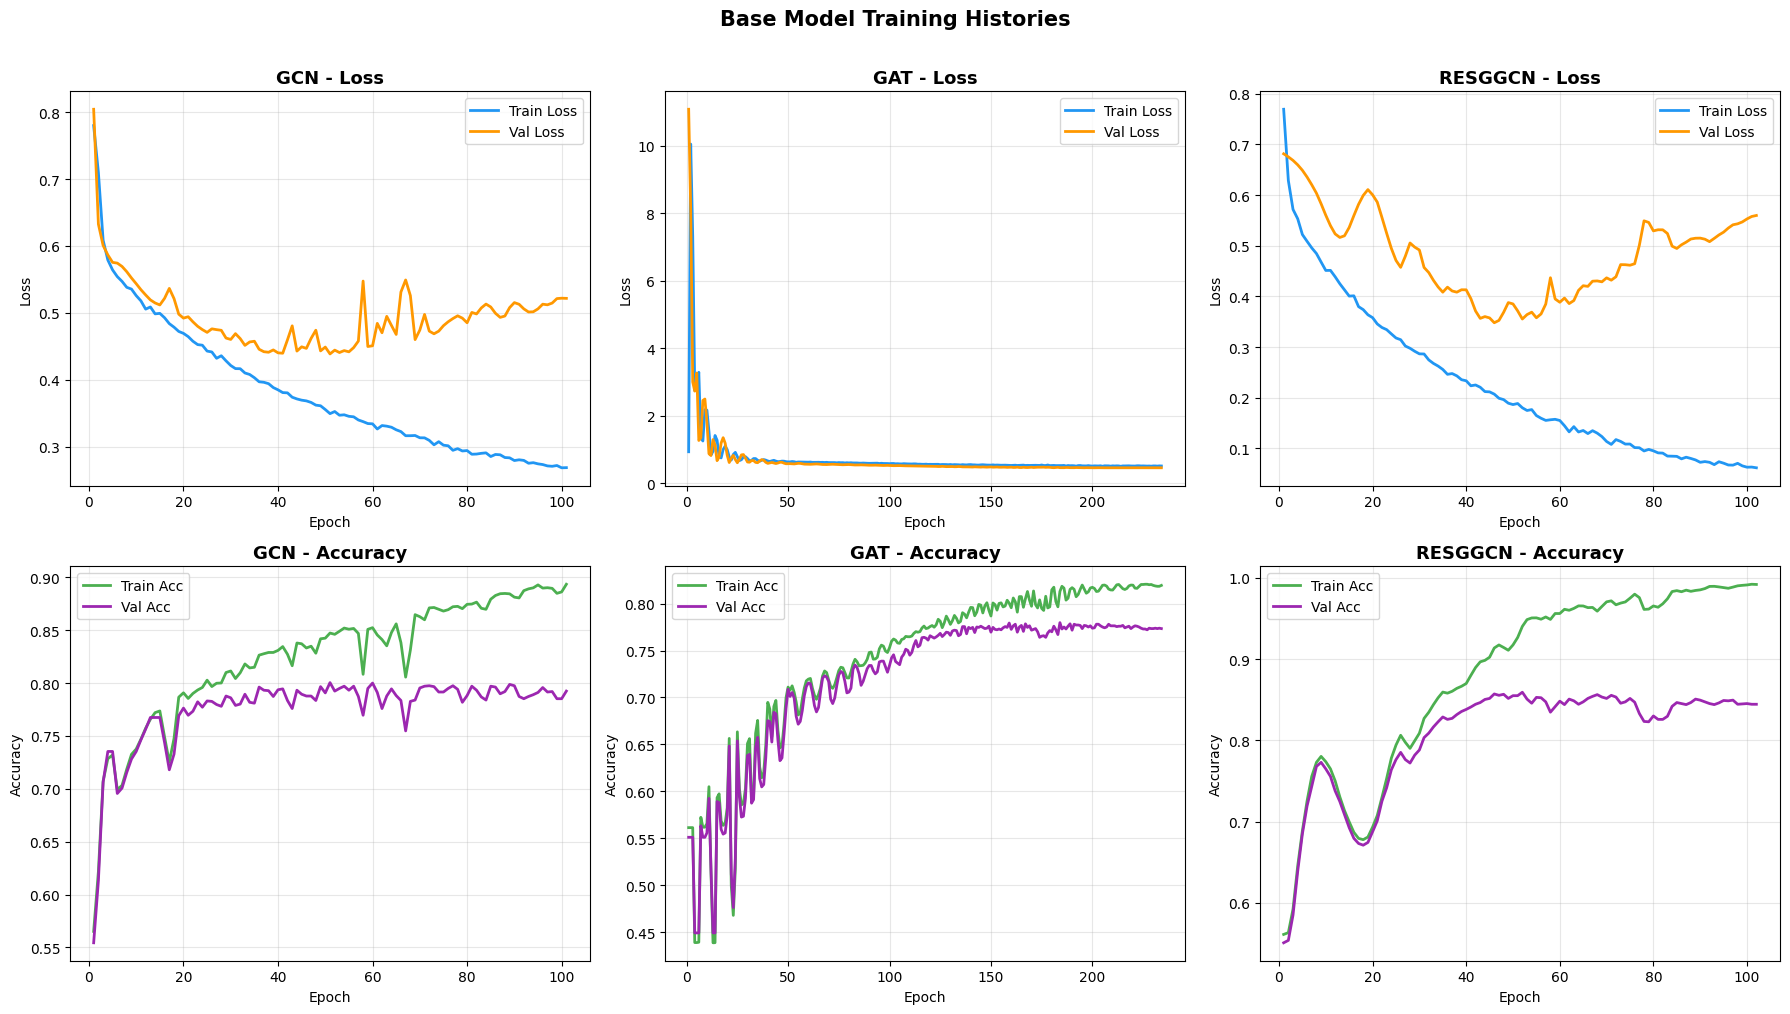

In [29]:
# ============================================================================
# Training History Visualization
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, model_name in enumerate(BASE_MODEL_NAMES):
    history = base_histories[model_name]
    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss plot
    axes[0, i].plot(epochs_range, history['train_loss'], label='Train Loss', color='#2196F3', linewidth=2)
    axes[0, i].plot(epochs_range, history['val_loss'], label='Val Loss', color='#FF9800', linewidth=2)
    axes[0, i].set_title(f'{model_name} - Loss', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1, i].plot(epochs_range, history['train_acc'], label='Train Acc', color='#4CAF50', linewidth=2)
    axes[1, i].plot(epochs_range, history['val_acc'], label='Val Acc', color='#9C27B0', linewidth=2)
    axes[1, i].set_title(f'{model_name} - Accuracy', fontsize=13, fontweight='bold')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Accuracy')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Base Model Training Histories', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**11. Stacking Ensemble Training**


In [30]:
# ============================================================================
# Extract Model Predictions (Probabilities)
# ============================================================================
@torch.no_grad()
def get_model_probabilities(model: nn.Module, data: Data) -> np.ndarray:
    """
    Get class probabilities from a trained model for all nodes.
    Returns: numpy array of shape (num_nodes, num_classes)
    """
    model.eval()
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)
    return probs.cpu().numpy()


print("Extracting probability predictions from all base models")

all_probs = {}
for model_name in BASE_MODEL_NAMES:
    model = base_models[model_name]
    probs = get_model_probabilities(model, graph_data)
    all_probs[model_name] = probs
    print(f"  {model_name}: shape {probs.shape}, range [{probs.min():.4f}, {probs.max():.4f}]")

# ============================================================================
# Build Meta-Features
# ============================================================================
# For binary classification, we use both class probabilities from each model
# Result: 3 models × 2 classes = 6 features

# Approach 1: Use bot probability only (simpler, less redundant)
meta_features_bot_only = np.column_stack([
    all_probs[name][:, 1] for name in BASE_MODEL_NAMES
])

# Approach 2: Use full probability vectors (recommended for richer information)
meta_features_full = np.column_stack([
    all_probs[name] for name in BASE_MODEL_NAMES
])

print(f"\nMeta-features (bot prob only): {meta_features_bot_only.shape}")
print(f"Meta-features (full probs): {meta_features_full.shape}")

# Will use the full probability vectors for richer information
meta_features = meta_features_full.astype(np.float32)

# Feature names for interpretability
meta_feature_names = []
for name in BASE_MODEL_NAMES:
    meta_feature_names.append(f'{name}_prob_human')
    meta_feature_names.append(f'{name}_prob_bot')
print(f"Meta-feature names: {meta_feature_names}")

Extracting probability predictions from all base models
  GCN: shape (11826, 2), range [0.0000, 1.0000]
  GAT: shape (11826, 2), range [0.0001, 0.9999]
  RESGGCN: shape (11826, 2), range [0.0000, 1.0000]

Meta-features (bot prob only): (11826, 3)
Meta-features (full probs): (11826, 6)
Meta-feature names: ['GCN_prob_human', 'GCN_prob_bot', 'GAT_prob_human', 'GAT_prob_bot', 'RESGGCN_prob_human', 'RESGGCN_prob_bot']


In [31]:
# ============================================================================
# Prepare Training Data for Meta-Learner
# ============================================================================
# Get labels as numpy array
y_all = graph_data.y.cpu().numpy()

# Get masks
train_mask = graph_data.train_mask.cpu().numpy()
val_mask = graph_data.val_mask.cpu().numpy()
test_mask = graph_data.test_mask.cpu().numpy()

# Extract features and labels for each split
X_train_meta = meta_features[train_mask]
y_train_meta = y_all[train_mask]

X_val_meta = meta_features[val_mask]
y_val_meta = y_all[val_mask]

X_test_meta = meta_features[test_mask]
y_test_meta = y_all[test_mask]

print(f"Meta-learner training data:")
print(f"  X_train: {X_train_meta.shape}, y_train: {y_train_meta.shape}")
print(f"  X_val:   {X_val_meta.shape}, y_val:   {y_val_meta.shape}")
print(f"  X_test:  {X_test_meta.shape}, y_test:  {y_test_meta.shape}")
print(f"\nClass distribution in training set:")
print(f"  Humans: {(y_train_meta == 0).sum()}, Bots: {(y_train_meta == 1).sum()}")

Meta-learner training data:
  X_train: (8278, 6), y_train: (8278,)
  X_val:   (2365, 6), y_val:   (2365,)
  X_test:  (1183, 6), y_test:  (1183,)

Class distribution in training set:
  Humans: 3632, Bots: 4646


In [32]:
# ============================================================================
# Train XGBoost Meta-Learner
# ============================================================================
def train_xgboost_meta(X_train: np.ndarray, y_train: np.ndarray,
                       X_val: np.ndarray, y_val: np.ndarray,
                       feature_names: list = None) -> xgb.XGBClassifier:
    """
    Train an XGBoost classifier as the meta-learner for the stacking ensemble.

    Uses validation set for early stopping.

    Args:
        X_train: Training meta-features (model probabilities)
        y_train: Training labels
        X_val: Validation meta-features
        y_val: Validation labels
        feature_names: Names of meta-features

    Returns:
        Trained XGBoost classifier
    """
    # Compute class weight to handle imbalance
    n_bots = (y_train == 1).sum()
    n_humans = (y_train == 0).sum()
    scale_pos_weight = n_humans / max(n_bots, 1)

    print(f"  Scale positive weight: {scale_pos_weight:.2f}")
    print(f"  (Bot class weight adjusted for {n_humans} humans vs {n_bots} bots)")

    # XGBoost classifier
    xgb_meta = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='auc',
        early_stopping_rounds=30,
        random_state=SEED,
        use_label_encoder=False,
        verbosity=1
    )

    print(f"\n  Training XGBoost meta-learner")
    print(f"  Hyperparameters: n_estimators={200}, max_depth=3, lr=0.05")

    xgb_meta.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    print(f"\n  Best iteration: {xgb_meta.best_iteration}")
    print(f"  Best validation score: {xgb_meta.best_score:.4f}")

    return xgb_meta


# Alternative: Use Train+Val together for final training
# This follows the stacking approach where meta-learner is trained on all non-test data
X_trainval_meta = np.vstack([X_train_meta, X_val_meta])
y_trainval_meta = np.concatenate([y_train_meta, y_val_meta])

# Train the meta-learner
xgb_meta_learner = train_xgboost_meta(
    X_train=X_train_meta,
    y_train=y_train_meta,
    X_val=X_val_meta,
    y_val=y_val_meta,
    feature_names=meta_feature_names
)

  Scale positive weight: 0.78
  (Bot class weight adjusted for 3632 humans vs 4646 bots)

  Training XGBoost meta-learner
  Hyperparameters: n_estimators=200, max_depth=3, lr=0.05

  Best iteration: 30
  Best validation score: 0.9267


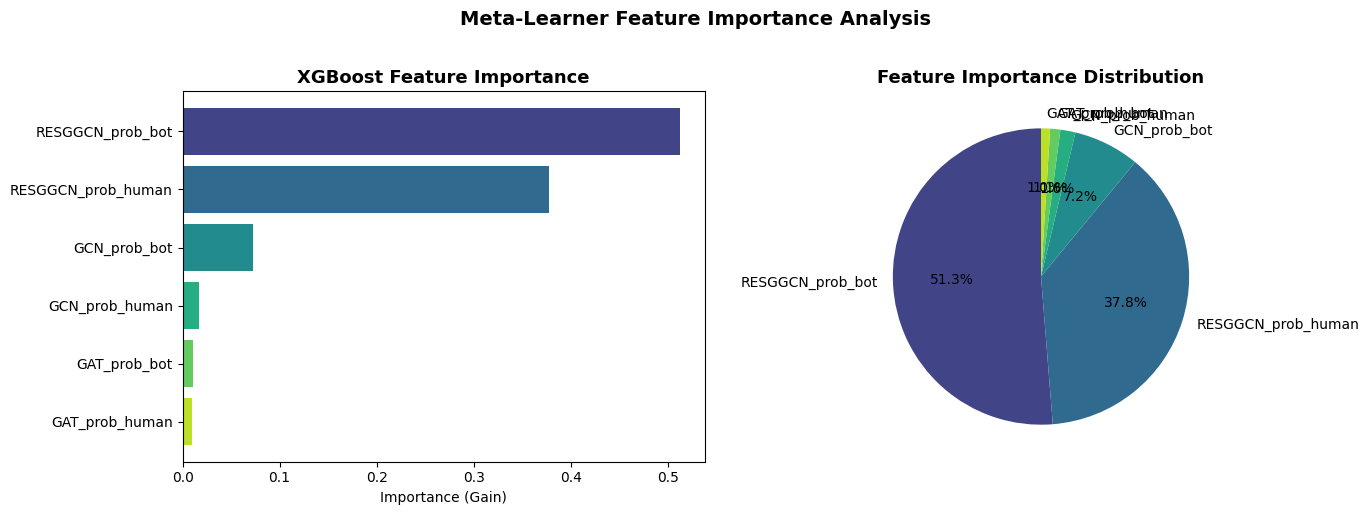


Feature Importance:
  RESGGCN_prob_bot              : 0.5127
  RESGGCN_prob_human            : 0.3776
  GCN_prob_bot                  : 0.0723
  GCN_prob_human                : 0.0164
  GAT_prob_bot                  : 0.0111
  GAT_prob_human                : 0.0099


In [33]:
# ============================================================================
# Feature Importance Analysis
# ============================================================================
def plot_xgboost_importance(model: xgb.XGBClassifier, feature_names: list):
    """Plot XGBoost feature importance."""
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(indices)))
    axes[0].barh(range(len(indices)), importance[indices], color=colors)
    axes[0].set_yticks(range(len(indices)))
    axes[0].set_yticklabels([feature_names[i] for i in indices])
    axes[0].set_xlabel('Importance (Gain)')
    axes[0].set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
    axes[0].invert_yaxis()

    # Pie chart
    axes[1].pie(importance[indices], labels=[feature_names[i] for i in indices],
               autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title('Feature Importance Distribution', fontsize=13, fontweight='bold')

    plt.suptitle('Meta-Learner Feature Importance Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print importance values
    print("\nFeature Importance:")
    for i in indices:
        print(f"  {feature_names[i]:30s}: {importance[i]:.4f}")


plot_xgboost_importance(xgb_meta_learner, meta_feature_names)

**12. Model Evaluation**


In [34]:
# ============================================================================
# Evaluate Base Models on Test Set
# ============================================================================
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray = None) -> dict:
    """
    Compute comprehensive classification metrics.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        y_prob: Predicted probabilities for positive class (bot)

    Returns:
        Dictionary of metrics
    """
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        metrics['AUROC'] = roc_auc_score(y_true, y_prob)

    return metrics


# Evaluate base models
y_test_true = y_test_meta  # Already extracted
base_model_results = {}

print("=" * 70)
print("BASE MODEL RESULTS (Test Set)")
print("=" * 70)

for model_name in BASE_MODEL_NAMES:
    model = base_models[model_name]
    test_eval = evaluate(model, graph_data, graph_data.test_mask)

    y_pred = test_eval['predictions'].numpy()
    y_prob = test_eval['probabilities'].numpy()[:, 1]  # Bot probability

    metrics = compute_metrics(y_test_true, y_pred, y_prob)
    base_model_results[model_name] = metrics

    print(f"\n{model_name}:")
    print(f"  Accuracy:   {metrics['Accuracy']:.4f}")
    print(f"  Precision:  {metrics['Precision']:.4f}")
    print(f"  Recall:     {metrics['Recall']:.4f}")
    print(f"  F1-Score:   {metrics['F1-Score']:.4f}")
    print(f"  AUROC:      {metrics.get('AUROC', 'N/A'):.4f}" if 'AUROC' in metrics else f"  AUROC:      N/A")

BASE MODEL RESULTS (Test Set)

GCN:
  Accuracy:   0.7828
  Precision:  0.7888
  Recall:     0.8172
  F1-Score:   0.8028
  AUROC:      0.8636

GAT:
  Accuracy:   0.7515
  Precision:  0.7276
  Recall:     0.8641
  F1-Score:   0.7900
  AUROC:      0.8334

RESGGCN:
  Accuracy:   0.8529
  Precision:  0.8416
  Recall:     0.8969
  F1-Score:   0.8684
  AUROC:      0.9190


In [35]:
# ============================================================================
# Evaluate Stacking Ensemble on Test Set
# ============================================================================
print("\n" + "=" * 70)
print("STACKING ENSEMBLE RESULTS (Test Set)")
print("=" * 70)

# Get predictions from XGBoost meta-learner
y_pred_stacking = xgb_meta_learner.predict(X_test_meta)
y_prob_stacking = xgb_meta_learner.predict_proba(X_test_meta)[:, 1]

stacking_metrics = compute_metrics(y_test_true, y_pred_stacking, y_prob_stacking)

print(f"\nXGBoost Stacking Ensemble:")
print(f"  Accuracy:   {stacking_metrics['Accuracy']:.4f}")
print(f"  Precision:  {stacking_metrics['Precision']:.4f}")
print(f"  Recall:     {stacking_metrics['Recall']:.4f}")
print(f"  F1-Score:   {stacking_metrics['F1-Score']:.4f}")
print(f"  AUROC:      {stacking_metrics.get('AUROC', 'N/A'):.4f}" if 'AUROC' in stacking_metrics else f"  AUROC:      N/A")


STACKING ENSEMBLE RESULTS (Test Set)

XGBoost Stacking Ensemble:
  Accuracy:   0.8394
  Precision:  0.8560
  Recall:     0.8453
  F1-Score:   0.8506
  AUROC:      0.9123


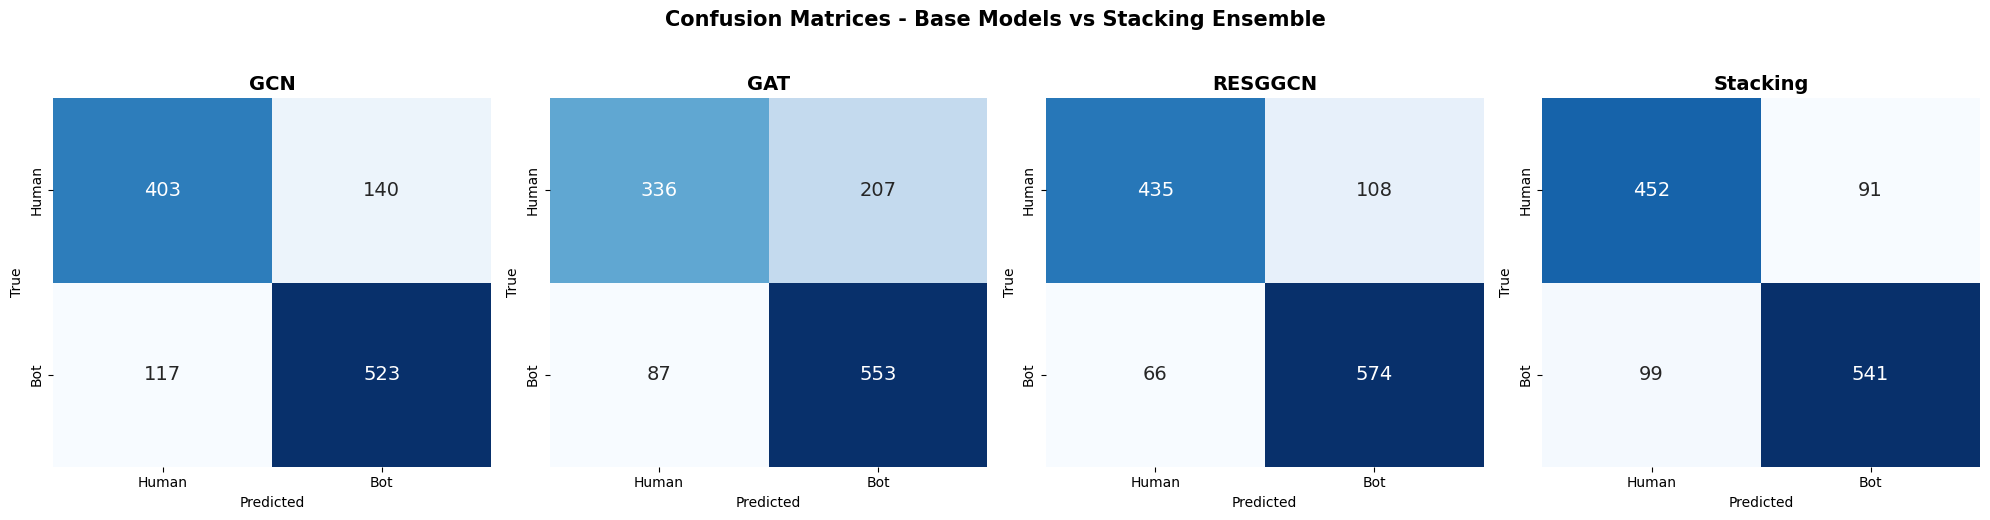

In [36]:
# ============================================================================
# Confusion Matrix
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_model_results = list(base_model_results.items()) + [('Stacking', stacking_metrics)]

for ax, (name, _) in zip(axes, all_model_results):
    if name == 'Stacking':
        cm = confusion_matrix(y_test_true, y_pred_stacking)
    else:
        model = base_models[name]
        test_eval = evaluate(model, graph_data, graph_data.test_mask)
        y_pred = test_eval['predictions'].numpy()
        cm = confusion_matrix(y_test_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'],
                cbar=False, annot_kws={'size': 14})
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices - Base Models vs Stacking Ensemble',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

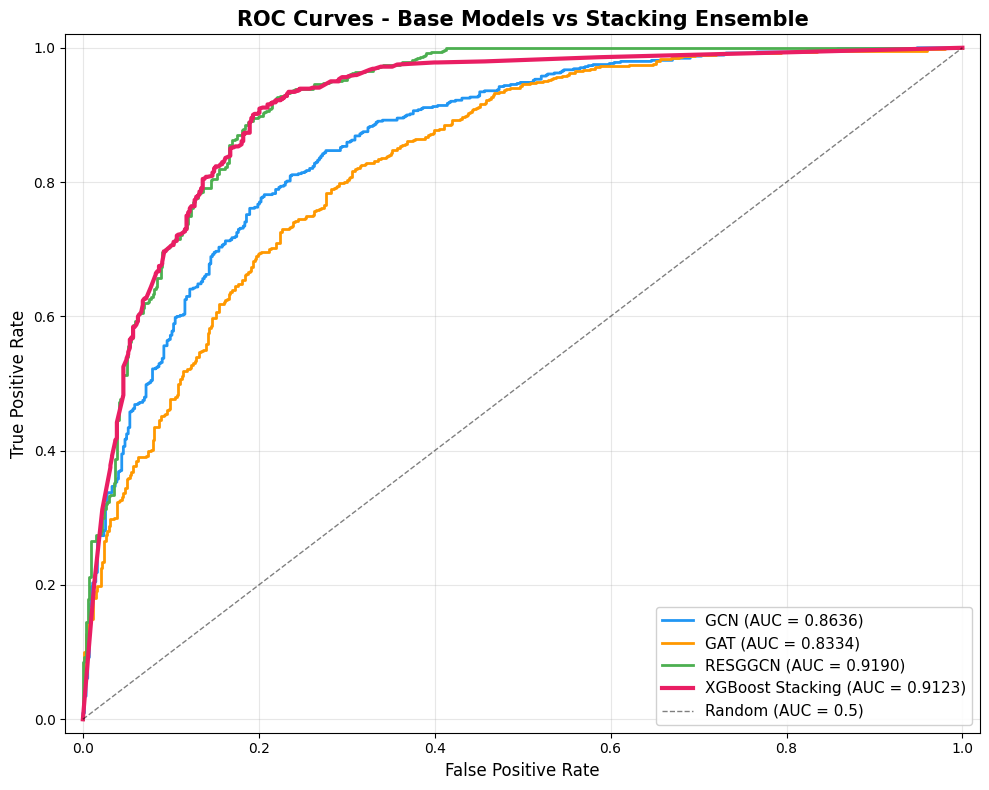

In [37]:
# ============================================================================
# ROC Curves
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'GCN': '#2196F3', 'GAT': '#FF9800', 'RESGGCN': '#4CAF50', 'Stacking': '#E91E63'}

for model_name in BASE_MODEL_NAMES:
    model = base_models[model_name]
    test_eval = evaluate(model, graph_data, graph_data.test_mask)
    y_prob = test_eval['probabilities'].numpy()[:, 1]

    fpr, tpr, _ = roc_curve(y_test_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[model_name], lw=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')

# Stacking ensemble
fpr, tpr, _ = roc_curve(y_test_true, y_prob_stacking)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color=colors['Stacking'], lw=3, linestyle='-',
        label=f'XGBoost Stacking (AUC = {roc_auc:.4f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Base Models vs Stacking Ensemble', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# ============================================================================
# Classification Report
# ============================================================================
print("=" * 70)
print("CLASSIFICATION REPORT - XGBoost Stacking Ensemble")
print("=" * 70)
print()
print(classification_report(y_test_true, y_pred_stacking,
                            target_names=['Human', 'Bot'],
                            digits=4))

# Also show per-class breakdown in a cleaner format
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_true, y_pred_stacking, labels=[0, 1]
)

print("\n" + "=" * 70)
print("PER-CLASS METRICS SUMMARY")
print("=" * 70)
print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 56)
for i, cls_name in enumerate(['Human', 'Bot']):
    print(f"{cls_name:<10} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")

CLASSIFICATION REPORT - XGBoost Stacking Ensemble

              precision    recall  f1-score   support

       Human     0.8203    0.8324    0.8263       543
         Bot     0.8560    0.8453    0.8506       640

    accuracy                         0.8394      1183
   macro avg     0.8382    0.8389    0.8385      1183
weighted avg     0.8396    0.8394    0.8395      1183


PER-CLASS METRICS SUMMARY
Class      Precision    Recall       F1-Score     Support   
--------------------------------------------------------
Human      0.8203       0.8324       0.8263       543       
Bot        0.8560       0.8453       0.8506       640       


**13. Results Visualization**


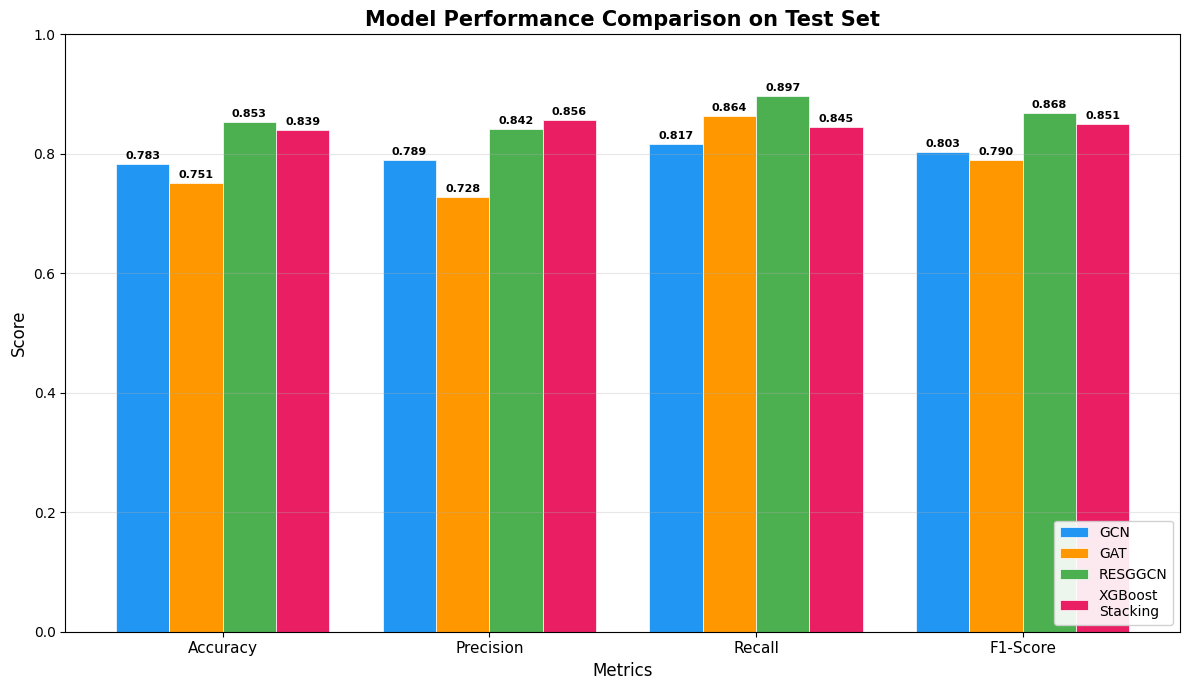

In [39]:
# ============================================================================
# Metrics Comparison Bar Chart
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7))

model_names = BASE_MODEL_NAMES + ['XGBoost\nStacking']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

all_metrics = [base_model_results[name] for name in BASE_MODEL_NAMES] + [stacking_metrics]

x = np.arange(len(metrics_names))
width = 0.2
colors_bars = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

for i, (name, metrics) in enumerate(zip(model_names, all_metrics)):
    values = [metrics[m] for m in metrics_names]
    bars = ax.bar(x + i * width, values, width, label=name, color=colors_bars[i], edgecolor='white', linewidth=0.5)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison on Test Set', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

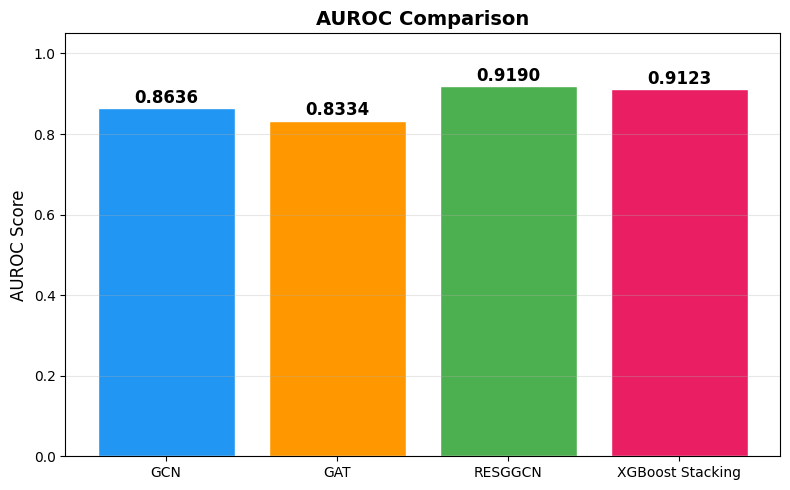

In [40]:
# ============================================================================
# AUROC Comparison
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

auroc_values = []
labels_auroc = []

for model_name in BASE_MODEL_NAMES:
    auroc_values.append(base_model_results[model_name].get('AUROC', 0))
    labels_auroc.append(model_name)

auroc_values.append(stacking_metrics.get('AUROC', 0))
labels_auroc.append('XGBoost Stacking')

colors_auroc = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
bars = ax.bar(labels_auroc, auroc_values, color=colors_auroc, edgecolor='white', linewidth=1)

for bar, val in zip(bars, auroc_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('AUROC Score', fontsize=12)
ax.set_title('AUROC Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

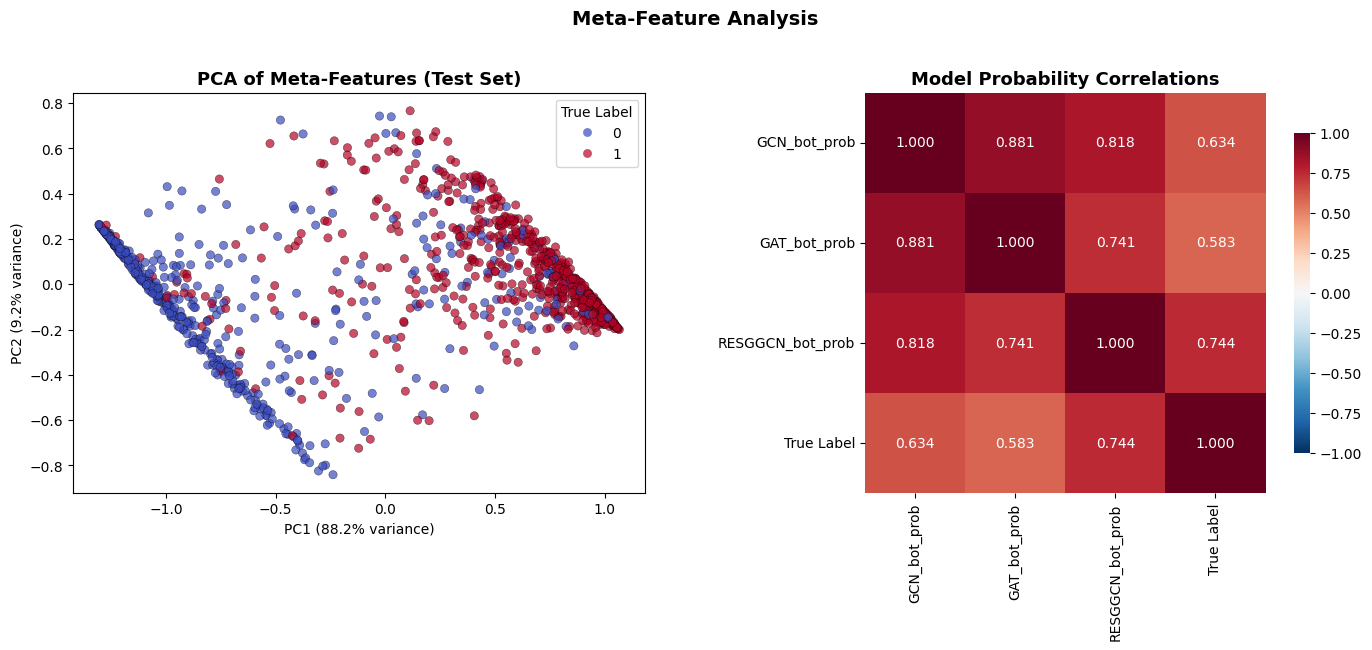

In [41]:
# ============================================================================
# Meta-Feature Space Visualization
# ============================================================================
# Visualize the 2D projection of meta-features to understand the stacking space

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA projection
pca = PCA(n_components=2)
meta_2d = pca.fit_transform(meta_features[test_mask])

scatter = axes[0].scatter(meta_2d[:, 0], meta_2d[:, 1], c=y_test_true,
                          cmap='coolwarm', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA of Meta-Features (Test Set)', fontsize=13, fontweight='bold')
legend1 = axes[0].legend(*scatter.legend_elements(), title='True Label', loc='best')

# Show model probability correlations
prob_df = pd.DataFrame({
    'GCN_bot_prob': all_probs['GCN'][test_mask, 1],
    'GAT_bot_prob': all_probs['GAT'][test_mask, 1],
    'RESGGCN_bot_prob': all_probs['RESGGCN'][test_mask, 1],
    'True Label': y_test_true
})

corr = prob_df.corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=axes[1], fmt='.3f', cbar_kws={'shrink': 0.8})
axes[1].set_title('Model Probability Correlations', fontsize=13, fontweight='bold')

plt.suptitle('Meta-Feature Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**14. Final Prediction**


In [42]:
# ============================================================================
# Final Predictions Summary
# ============================================================================
# Get test user IDs
test_user_ids = [uid for uid in splits_dict['test'] if uid in labels_dict]

# Build results dataframe
results_df = pd.DataFrame({
    'user_id': test_user_ids[:len(y_test_true)],
    'true_label': ['Human' if l == 0 else 'Bot' for l in y_test_true],
    'predicted_label': ['Human' if p == 0 else 'Bot' for p in y_pred_stacking],
    'bot_probability': y_prob_stacking,
    'correct': y_test_true == y_pred_stacking,
    'GCN_bot_prob': all_probs['GCN'][test_mask, 1],
    'GAT_bot_prob': all_probs['GAT'][test_mask, 1],
    'RESGGCN_bot_prob': all_probs['RESGGCN'][test_mask, 1],
})

print("=" * 70)
print("FINAL PREDICTIONS - Test Set Sample")
print("=" * 70)
print(f"\nTotal test samples: {len(results_df)}")
print(f"Correct predictions: {results_df['correct'].sum()}")
print(f"Incorrect predictions: {(~results_df['correct']).sum()}")
print(f"Overall accuracy: {results_df['correct'].mean():.4f}")

# Show sample predictions
print(f"\n{'─'*70}")
print("Sample Predictions (first 10):")
print(f"{'─'*70}")
display(results_df.head(10).style.applymap(
    lambda x: 'background-color: #C8E6C9' if x == True else ('background-color: #FFCDD2' if x == False else ''),
    subset=['correct']
))

# Show misclassifications
print(f"\n{'─'*70}")
print("Misclassified Examples (first 10):")
print(f"{'─'*70}")
misclassified = results_df[~results_df['correct']]
display(misclassified.head(10).style.applymap(
    lambda x: 'background-color: #FFCDD2' if x == False else '',
    subset=['correct']
))

FINAL PREDICTIONS - Test Set Sample

Total test samples: 1183
Correct predictions: 993
Incorrect predictions: 190
Overall accuracy: 0.8394

──────────────────────────────────────────────────────────────────────
Sample Predictions (first 10):
──────────────────────────────────────────────────────────────────────


,user_id,true_label,predicted_label,bot_probability,correct,GCN_bot_prob,GAT_bot_prob,RESGGCN_bot_prob
0,u1188812492010487808,Bot,Bot,0.886517,True,0.941340,0.852998,0.993212
1,u155659213,Human,Human,0.106638,True,0.001495,0.124745,0.000000
2,u147725246,Human,Human,0.106638,True,0.110598,0.356242,0.000009
3,u1296248637194895360,Bot,Human,0.106638,False,0.063447,0.026839,0.010763
4,u1339835893,Human,Human,0.106638,True,0.003367,0.147189,0.000000
5,u2575245955,Human,Human,0.106638,True,0.068990,0.147463,0.000081
6,u20177423,Human,Human,0.106638,True,0.121945,0.273940,0.000163
7,u29758446,Human,Human,0.106638,True,0.155414,0.218928,0.000112
8,u29562422,Human,Human,0.106638,True,0.078448,0.381514,0.000006
9,u458566509,Bot,Bot,0.873327,True,0.552259,0.584761,0.948960



──────────────────────────────────────────────────────────────────────
Misclassified Examples (first 10):
──────────────────────────────────────────────────────────────────────


,user_id,true_label,predicted_label,bot_probability,correct,GCN_bot_prob,GAT_bot_prob,RESGGCN_bot_prob
3,u1296248637194895360,Bot,Human,0.106638,False,0.063447,0.026839,0.010763
23,u1271061042685239298,Human,Bot,0.831689,False,0.624744,0.710334,0.907350
39,u1080452069306249216,Human,Bot,0.546116,False,0.589565,0.396137,0.738832
50,u3385482372,Human,Bot,0.881834,False,0.444468,0.601504,0.990815
57,u783432377863286788,Human,Bot,0.831689,False,0.566434,0.497390,0.910793
70,u1229252334221451266,Bot,Human,0.225698,False,0.765743,0.553723,0.423374
75,u316429052,Bot,Human,0.408201,False,0.855472,0.839012,0.683192
78,u57096687,Bot,Human,0.118537,False,0.223737,0.350002,0.105272
93,u1029587565014339584,Human,Bot,0.888258,False,0.999097,0.888124,0.996824
111,u3242757412,Human,Bot,0.886517,False,0.891711,0.666286,0.984700


**15. XAI Reasons for Bot and Human Predictions**

In [43]:
# ============================================================================
# XAI Explanation for Each Bot/Human Prediction (TreeSHAP)
# ============================================================================
# XGBoost's pred_contribs returns exact TreeSHAP contributions. Positive values
# push the prediction toward Bot; negative values push it toward Human.
xai_contributions = xgb_meta_learner.get_booster().predict(
    xgb.DMatrix(X_test_meta), pred_contribs=True
)[:, :-1]  # Exclude the final bias/base-value column

friendly_feature_names = {
    f'{model}_prob_human': f"{model}'s Human probability"
    for model in BASE_MODEL_NAMES
}
friendly_feature_names.update({
    f'{model}_prob_bot': f"{model}'s Bot probability"
    for model in BASE_MODEL_NAMES
})

def explain_prediction(sample_index, top_n=3):
    """Return a plain-language XAI reason for one Bot/Human prediction."""
    predicted_class = int(y_pred_stacking[sample_index])
    predicted_label = 'Bot' if predicted_class == 1 else 'Human'
    bot_probability = float(y_prob_stacking[sample_index])
    confidence = bot_probability if predicted_class == 1 else 1.0 - bot_probability
    contributions = xai_contributions[sample_index]

    # Keep features whose SHAP direction supports the predicted class.
    support = contributions if predicted_class == 1 else -contributions
    ranked = np.argsort(support)[::-1]
    supporting_features = [i for i in ranked if support[i] > 0][:top_n]

    # This fallback is only needed if the model bias alone determines the class.
    if not supporting_features:
        supporting_features = list(np.argsort(np.abs(contributions))[::-1][:top_n])

    reasons = []
    for feature_index in supporting_features:
        feature_name = meta_feature_names[feature_index]
        feature_value = X_test_meta[sample_index, feature_index]
        impact = contributions[feature_index]
        direction = 'Bot' if impact > 0 else 'Human'
        reasons.append(
            f"{friendly_feature_names[feature_name]} was {feature_value:.3f} "
            f"(pushed toward {direction}; SHAP impact {impact:+.3f})"
        )

    return (
        f"Predicted {predicted_label} with {confidence:.1%} confidence because "
        + '; '.join(reasons)
        + '. '
        + ('Positive SHAP values support Bot.' if predicted_class == 1
           else 'Negative SHAP values support Human.')
    )

# Add one explanation to every prediction without changing the existing model.
results_df['xai_reason'] = [explain_prediction(i) for i in range(len(results_df))]

# Display one Bot and one Human example (when both classes are present).
xai_examples = pd.concat([
    results_df[results_df['predicted_label'] == 'Bot'].head(1),
    results_df[results_df['predicted_label'] == 'Human'].head(1)
])


In [45]:
# Print complete explanations
for _, row in xai_examples.iterrows():
    print("="*100)
    print(f"User ID          : {row['user_id']}")
    print(f"Predicted Label  : {row['predicted_label']}")
    print(f"Bot Probability  : {row['bot_probability']:.6f}")
    print("\nComplete XAI Explanation:")
    print(row['xai_reason'])
    print("="*100)

User ID          : u1188812492010487808
Predicted Label  : Bot
Bot Probability  : 0.886517

Complete XAI Explanation:
Predicted Bot with 88.7% confidence because RESGGCN's Human probability was 0.007 (pushed toward Bot; SHAP impact +1.952); RESGGCN's Bot probability was 0.993 (pushed toward Bot; SHAP impact +1.590); GCN's Bot probability was 0.941 (pushed toward Bot; SHAP impact +0.016). Positive SHAP values support Bot.
User ID          : u155659213
Predicted Label  : Human
Bot Probability  : 0.106638

Complete XAI Explanation:
Predicted Human with 89.3% confidence because RESGGCN's Human probability was 1.000 (pushed toward Human; SHAP impact -2.086); RESGGCN's Bot probability was 0.000 (pushed toward Human; SHAP impact -1.597); GCN's Bot probability was 0.001 (pushed toward Human; SHAP impact -0.034). Negative SHAP values support Human.


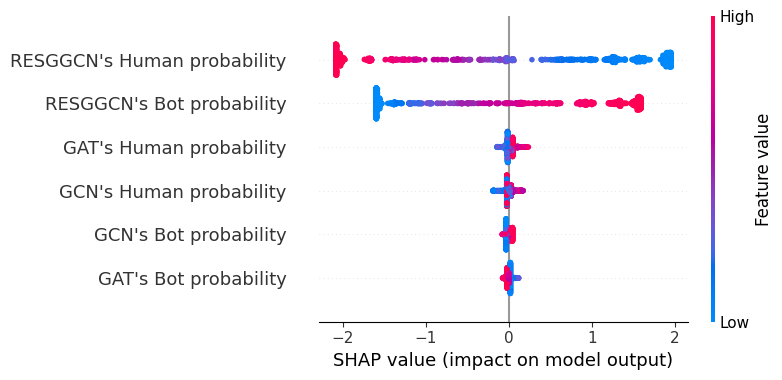


Bot prediction | User: u1188812492010487808 | Confidence: 88.7%


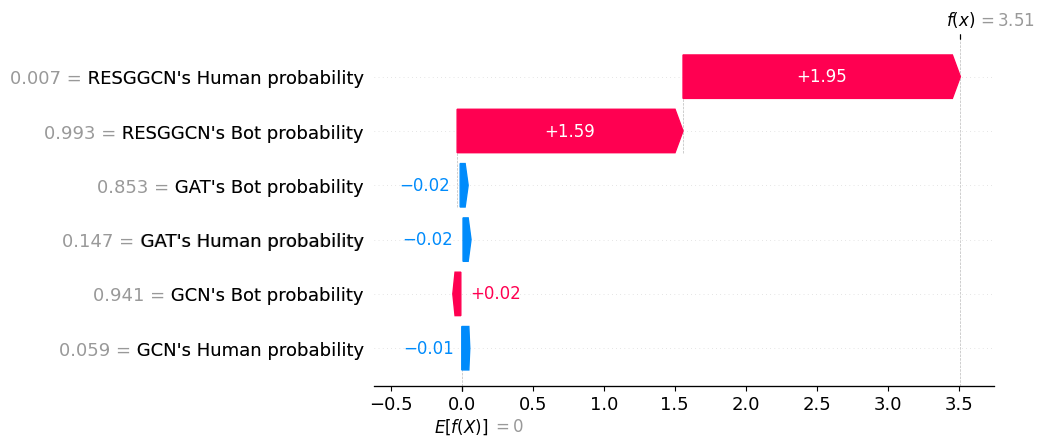


Human prediction | User: u155659213 | Confidence: 89.3%


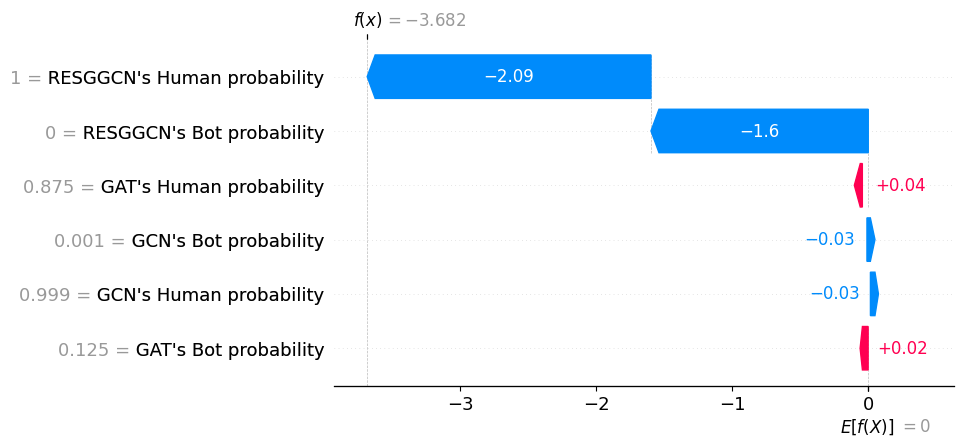

In [46]:
# ============================================================================
# SHAP Plots for the Stacking Ensemble
# ============================================================================
import shap

# Obtain SHAP contributions and the model's base value.
shap_output = xgb_meta_learner.get_booster().predict(
    xgb.DMatrix(X_test_meta),
    pred_contribs=True
)

shap_values = shap_output[:, :-1]
shap_base_values = shap_output[:, -1]

plot_feature_names = [
    friendly_feature_names[name] for name in meta_feature_names
]

# ============================================================================
# 1. Global SHAP Summary Plot
# ============================================================================
# Shows which model probabilities have the greatest overall influence.
shap.summary_plot(
    shap_values,
    X_test_meta,
    feature_names=plot_feature_names,
    plot_type="dot",
    max_display=len(plot_feature_names),
    show=True
)

# ============================================================================
# 2. Local SHAP Waterfall Plots
# ============================================================================
# Display one Bot and one Human explanation.
for predicted_class, class_name in [(1, "Bot"), (0, "Human")]:

    matching_indices = np.where(y_pred_stacking == predicted_class)[0]

    if len(matching_indices) == 0:
        print(f"No {class_name} prediction is available to plot.")
        continue

    sample_index = matching_indices[0]
    bot_probability = float(y_prob_stacking[sample_index])
    confidence = (
        bot_probability
        if predicted_class == 1
        else 1.0 - bot_probability
    )

    print(
        f"\n{class_name} prediction | "
        f"User: {results_df.iloc[sample_index]['user_id']} | "
        f"Confidence: {confidence:.1%}"
    )

    sample_explanation = shap.Explanation(
        values=shap_values[sample_index],
        base_values=shap_base_values[sample_index],
        data=X_test_meta[sample_index],
        feature_names=plot_feature_names
    )

    shap.plots.waterfall(
        sample_explanation,
        max_display=len(plot_feature_names),
        show=True
    )